In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve

In [2]:
df=pd.read_csv(r"C:\Users\shreyash\Desktop\Fraud Detection\data\creditcard.csv")

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [4]:
df['Class'].value_counts()
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

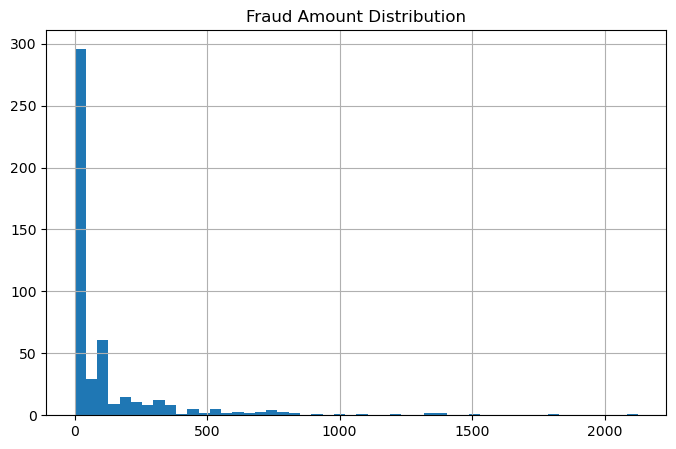

In [5]:
plt.figure(figsize=(8,5))
df[df['Class']==1]['Amount'].hist(bins=50)
plt.title("Fraud Amount Distribution")
plt.show()

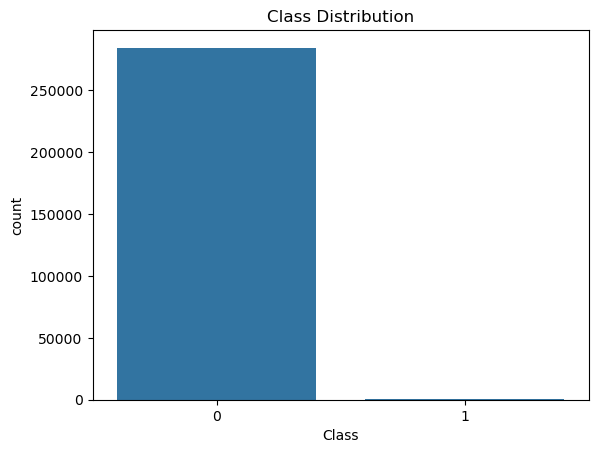

In [6]:
sns.countplot(x='Class',data=df)
plt.title("Class Distribution")
plt.show()

In [7]:

scaler=StandardScaler()
df['scaled_amount']=scaler.fit_transform(df[['Amount']])
df['scaled_time']=scaler.fit_transform(df[['Time']])
df=df.drop(['Amount','Time'],axis=1)

In [ ]:
x=df.drop('Class',axis=1)
y=df['Class']

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [10]:
lr=LogisticRegression(class_weight='balanced',max_iter=1000)
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
y_pred=lr.predict(x_test)
y_prob=lr.predict_proba(x_test)[:,1]

In [12]:
confusion_matrix(y_test,y_pred)

array([[55475,  1389],
       [    8,    90]])

In [13]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [14]:
roc_auc_score(y_test,y_prob)

0.9721667630895914

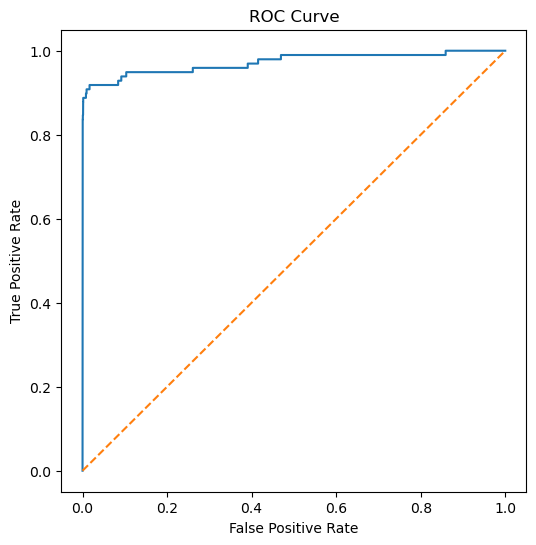

In [15]:
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [16]:
y_pred2=(y_prob>0.3).astype(int)
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56864
           1       0.03      0.92      0.05        98

    accuracy                           0.94     56962
   macro avg       0.51      0.93      0.51     56962
weighted avg       1.00      0.94      0.97     56962



In [17]:
rf=RandomForestClassifier(class_weight='balanced',n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
y_prob_rf=rf.predict_proba(x_test)[:,1]
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [18]:
feature_importance=pd.Series(rf.feature_importances_,index=x.columns)
feature_importance.sort_values(ascending=False).head(10)

V14    0.209830
V10    0.117478
V4     0.114355
V17    0.087216
V12    0.072471
V11    0.071893
V3     0.068797
V16    0.037353
V7     0.031213
V2     0.025358
dtype: float64

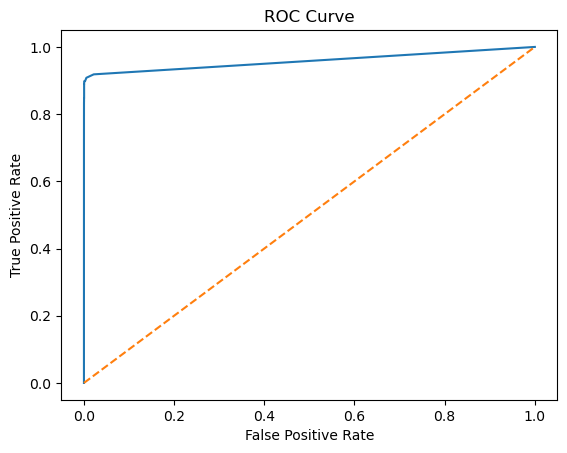

In [19]:
from sklearn.metrics import roc_curve

fpr,tpr,thresholds=roc_curve(y_test,y_prob_rf)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [20]:
df['Fraud_Probability']=rf.predict_proba(x)[:,1]
df['Prediction']=rf.predict(x)

df.to_csv(r"C:\Users\shreyash\Desktop\Fraud Detection\data\fraud_results.csv", index=False)